# RandomWalkChangepointParticipation1D Model Demo

This notebook demonstrates the `RandomWalkChangepointParticipation1D` model, which extends `RandomWalkChangepointMeanVar1D` ([see that notebook](RandomWalkChangepointMeanVar1D.ipynb)) to states where the underlying process is intermittently absent or disengaged -- e.g. an animal that periodically stops licking.

Non-participation is modeled as a soft, per-state, changepoint-blended **participation probability** that mixes between the state's normal innovation distribution and a zero-mean 'disengaged' distribution. This is a continuous mixture (not a discrete per-timestep indicator), so it remains compatible with ADVI. Missing observations (`NaN`) during non-participation are handled by fitting a full-length latent random walk path and only evaluating the likelihood at observed timepoints -- no explicit missing-data likelihood is needed.

In [1]:
import numpy as np
# Try to import matplotlib, create dummy if not available
try:
    import matplotlib.pyplot as plt
except ImportError:
    print('matplotlib not available - creating dummy plt object')
    class DummyPlt:
        def __getattr__(self, name):
            def dummy_func(*args, **kwargs):
                pass
            return dummy_func
    plt = DummyPlt()
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Add pytau to path
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), '..', '..'))

import pymc as pm
from pytau.changepoint_model import (
    RandomWalkChangepointParticipation1D,
    random_walk_changepoint_participation_1d,
    find_best_states,
)
import arviz as az

## Generate Test Data

Generated random walk of length: 300
Missing (NaN) points: 93 / 300
State (innovation) means: [2.5, 0.0, -2.3]
State (innovation) stds: [0.3, 2.0, 0.35]
Transition points (step index): [90, 200]
Disengaged/non-participating state: 2 (spans steps 90-200)


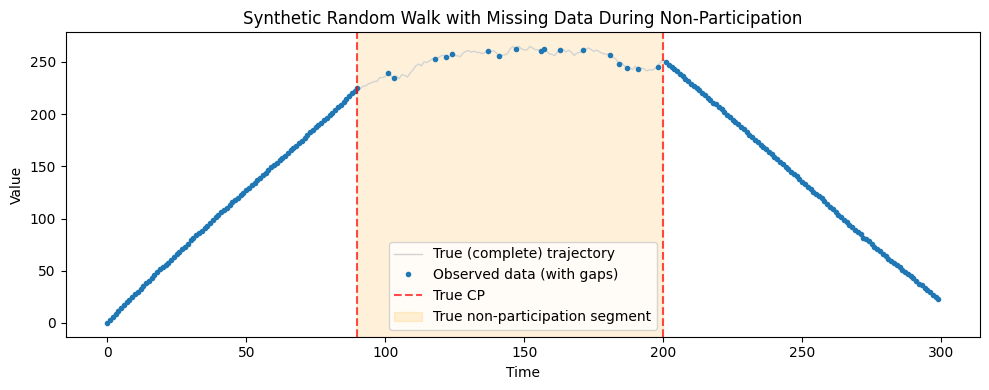

In [2]:
# Generate a synthetic 1D random walk with a "disengaged" (non-participating)
# state: its innovations are zero-mean/high-variance, and most points within
# it are blanked out (NaN) to simulate genuinely missing observations.
np.random.seed(0)
n_time = 300
n_states = 3
disengaged_state = 1  # 0-indexed state that represents non-participation

state_means = [2.5, 0.0, -2.3]     # innovation means (disengaged state uses 0)
state_stds = [0.3, 2.0, 0.35]      # innovation stds (disengaged state is wide)
transition_points = [90, 200]      # changepoints in the innovation (step) series
missing_frac = 0.85                # fraction of points blanked out in the disengaged segment

n_steps = n_time - 1
bounds = [0] + transition_points + [n_steps]

innovations = np.zeros(n_steps)
participation_mask = np.zeros(n_steps, dtype=bool)  # True = disengaged step
for i in range(n_states):
    start, end = bounds[i], bounds[i + 1]
    innovations[start:end] = np.random.normal(state_means[i], state_stds[i], end - start)
    if i == disengaged_state:
        participation_mask[start:end] = True

test_data_full = np.concatenate([[0.0], np.cumsum(innovations)])
test_data = test_data_full.copy()

# Blank out most points within the disengaged segment (data index i+1
# corresponds to innovation/step index i)
nan_candidates = np.where(participation_mask)[0] + 1
n_to_drop = int(missing_frac * len(nan_candidates))
drop_idx = np.random.choice(nan_candidates, size=n_to_drop, replace=False)
test_data[drop_idx] = np.nan

print(f"Generated random walk of length: {test_data.shape[0]}")
print(f"Missing (NaN) points: {np.isnan(test_data).sum()} / {test_data.shape[0]}")
print(f"State (innovation) means: {state_means}")
print(f"State (innovation) stds: {state_stds}")
print(f"Transition points (step index): {transition_points}")
print(
    f"Disengaged/non-participating state: {disengaged_state + 1} "
    f"(spans steps {bounds[disengaged_state]}-{bounds[disengaged_state + 1]})"
)

plt.figure(figsize=(10, 4))
plt.plot(test_data_full, '-', color='lightgray', linewidth=1, label='True (complete) trajectory')
plt.plot(test_data, 'o', markersize=3, label='Observed data (with gaps)')
for i, tp in enumerate(transition_points):
    plt.axvline(x=tp, color='red', linestyle='--', alpha=0.7, label='True CP' if i == 0 else None)
plt.axvspan(
    bounds[disengaged_state], bounds[disengaged_state + 1],
    color='orange', alpha=0.15, label='True non-participation segment',
)
plt.title('Synthetic Random Walk with Missing Data During Non-Participation')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()

## Initialize and Generate Model

In [3]:
# Initialize model
model = RandomWalkChangepointParticipation1D(
    data_array=test_data,
    n_states=n_states,
)

# Generate the PyMC model
pymc_model = model.generate_model()
print("Model generated successfully")
print(f"Model variables: {list(pymc_model.named_vars.keys())}")

Model generated successfully
Model variables: ['mu', 'sigma', 'participation_prob', 'sigma_disengaged', 'a_tau', 'b_tau', 'tau_latent', 'tau', 'innovations', 'x0', 'latent_path', 'obs']


## Fit Model with ADVI

In [4]:
# Fit the model using ADVI. A fixed random_seed is used for reproducibility --
# this model's participation-mixture likelihood was found to need it (ADVI's
# own stochastic gradient estimates are not controlled by np.random.seed).
print("Fitting model with ADVI...")
n_fit = 15000
n_samples = 500

with pymc_model:
    inference = pm.ADVI(random_seed=0)
    approx = pm.fit(n=n_fit, method=inference, random_seed=0)
    trace = approx.sample(draws=n_samples, random_seed=0)

print(f"Model fitting completed. Final ELBO: {approx.hist[-1]:.2f}")
print(f"Trace variables: {list(trace.posterior.data_vars)}")

Fitting model with ADVI...
Fitting: ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 Average Loss = 2.4561e+05
Model fitting completed. Final ELBO: 56778.46
Trace variables: ['a_tau', 'b_tau', 'innovations', 'latent_path', 'mu', 'participation_prob', 'sigma', 'sigma_disengaged', 'tau', 'tau_latent', 'x0']


## Extract and Analyze Fitted Parameters

In [5]:
mu_samples = trace.posterior['mu'].values
sigma_samples = trace.posterior['sigma'].values
participation_samples = trace.posterior['participation_prob'].values
tau_samples = trace.posterior['tau'].values
sigma_disengaged_samples = trace.posterior['sigma_disengaged'].values

mu_mean = mu_samples.mean(axis=(0, 1))
sigma_mean = sigma_samples.mean(axis=(0, 1))
participation_mean = participation_samples.mean(axis=(0, 1))
tau_mean = tau_samples.mean(axis=(0, 1))

print("Estimated innovation means (state):")
for state in range(n_states):
    print(f"  State {state + 1}: {mu_mean[state]:.3f} (true: {state_means[state]:.3f})")

print("\nEstimated innovation stds (state):")
for state in range(n_states):
    print(f"  State {state + 1}: {sigma_mean[state]:.3f} (true: {state_stds[state]:.3f})")

print("\nEstimated participation probability (state):")
for state in range(n_states):
    marker = "  <- true disengaged state" if state == disengaged_state else ""
    print(f"  State {state + 1}: {participation_mean[state]:.3f}{marker}")

print("\nEstimated changepoints (step index):")
for i in range(len(transition_points)):
    print(f"  CP {i + 1}: {tau_mean[i]:.1f} (true: {transition_points[i]})")

print(f"\nEstimated disengaged-innovation std: {sigma_disengaged_samples.mean():.3f} (true: {state_stds[disengaged_state]:.3f})")

inferred_disengaged_state = int(np.argmin(participation_mean))
print(
    f"\nState with lowest participation probability: State {inferred_disengaged_state + 1} "
    f"(true disengaged state: State {disengaged_state + 1})"
)

Estimated innovation means (state):
  State 1: 2.396 (true: 2.500)
  State 2: 0.170 (true: 0.000)
  State 3: -2.293 (true: -2.300)

Estimated innovation stds (state):
  State 1: 0.604 (true: 0.300)
  State 2: 0.675 (true: 2.000)
  State 3: 0.631 (true: 0.350)

Estimated participation probability (state):
  State 1: 0.951
  State 2: 0.484  <- true disengaged state
  State 3: 0.946

Estimated changepoints (step index):
  CP 1: 99.3 (true: 90)
  CP 2: 198.4 (true: 200)

Estimated disengaged-innovation std: 0.736 (true: 2.000)

State with lowest participation probability: State 2 (true disengaged state: State 2)


**Note on `sigma`/`participation_prob` identifiability:** when the estimated participation probability for a state is not close to 0 or 1 (as above, ~0.48), the innovation variance for that state is explained jointly by the mixture weighting *and* the two components' individual `sigma`/`sigma_disengaged` values, so those individual values can be underestimated relative to the true generating values. The participation probability itself -- the quantity this model is specifically designed to recover -- is the more reliable diagnostic for identifying non-participating states.

## Visualize Original Data vs Model Fit

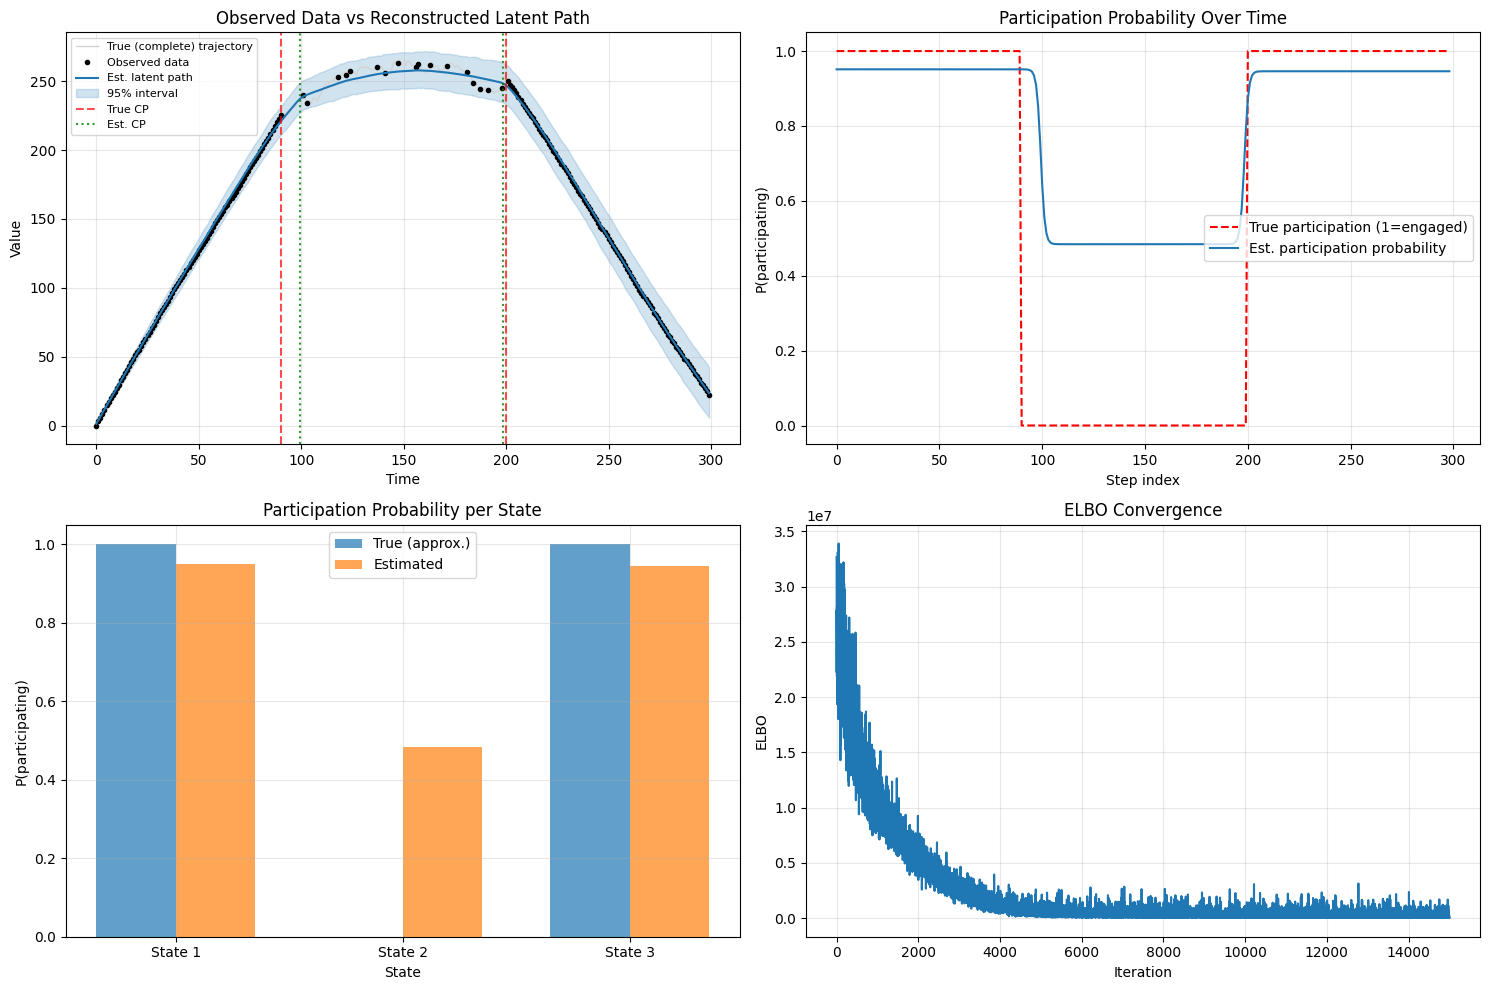

In [6]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def compute_weight_stack(idx, tau, n_states):
    length = len(idx)
    weight_stack = sigmoid(idx[np.newaxis, :] - tau[:, np.newaxis])
    weight_stack = np.concatenate([np.ones((1, length)), weight_stack], axis=0)
    inverse_stack = 1 - weight_stack[1:]
    inverse_stack = np.concatenate([inverse_stack, np.ones((1, length))], axis=0)
    return weight_stack * inverse_stack


idx = np.arange(n_steps)
weight_stack = compute_weight_stack(idx, tau_mean, n_states)
p_t_est = participation_mean.dot(weight_stack)

true_disengaged_t = participation_mask.astype(float)  # 1 where truly disengaged

latent_path_samples = trace.posterior['latent_path'].values  # (chain, draw, time)
latent_path_flat = latent_path_samples.reshape(-1, latent_path_samples.shape[-1])
latent_path_mean = latent_path_flat.mean(axis=0)
latent_path_lower = np.percentile(latent_path_flat, 2.5, axis=0)
latent_path_upper = np.percentile(latent_path_flat, 97.5, axis=0)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Observed data (with gaps) vs reconstructed latent path
ax = axes[0, 0]
ax.plot(test_data_full, color='lightgray', linewidth=1, label='True (complete) trajectory')
ax.plot(test_data, 'o', markersize=3, color='black', label='Observed data')
ax.plot(latent_path_mean, color='tab:blue', label='Est. latent path')
ax.fill_between(
    np.arange(n_time), latent_path_lower, latent_path_upper,
    color='tab:blue', alpha=0.2, label='95% interval',
)
for i, tp in enumerate(transition_points):
    ax.axvline(x=tp, color='red', linestyle='--', alpha=0.7, label='True CP' if i == 0 else None)
for i, tp in enumerate(tau_mean):
    ax.axvline(x=tp, color='green', linestyle=':', alpha=0.8, label='Est. CP' if i == 0 else None)
ax.set_title('Observed Data vs Reconstructed Latent Path')
ax.set_xlabel('Time')
ax.set_ylabel('Value')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 2. Participation probability over time: true vs estimated
ax = axes[0, 1]
ax.plot(1 - true_disengaged_t, color='red', linestyle='--', label='True participation (1=engaged)')
ax.plot(p_t_est, color='tab:blue', label='Est. participation probability')
ax.set_title('Participation Probability Over Time')
ax.set_xlabel('Step index')
ax.set_ylabel('P(participating)')
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)

# 3. True vs estimated participation probability per state
ax = axes[1, 0]
x_pos = np.arange(n_states)
width = 0.35
true_participation_per_state = [0.0 if i == disengaged_state else 1.0 for i in range(n_states)]
ax.bar(x_pos - width / 2, true_participation_per_state, width, label='True (approx.)', alpha=0.7)
ax.bar(x_pos + width / 2, participation_mean, width, label='Estimated', alpha=0.7)
ax.set_title('Participation Probability per State')
ax.set_xlabel('State')
ax.set_ylabel('P(participating)')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'State {i + 1}' for i in range(n_states)])
ax.legend()
ax.grid(True, alpha=0.3)

# 4. ELBO convergence
ax = axes[1, 1]
ax.plot(approx.hist)
ax.set_title('ELBO Convergence')
ax.set_xlabel('Iteration')
ax.set_ylabel('ELBO')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Posterior Predictive Check

Unlike `RandomWalkChangepointMeanVar1D`, the observation likelihood here only spans the **observed (non-`NaN`) timepoints** -- the latent path shown above is what reconstructs the full trajectory, including through gaps. So the PPC below compares posterior predictive draws of `obs` against the data only at the timepoints that were actually observed.

In [7]:
with pymc_model:
    ppc = pm.sample_posterior_predictive(trace, var_names=["obs"], random_seed=0)

ppc_samples = ppc.posterior_predictive["obs"].values
ppc_samples = ppc_samples.reshape(-1, ppc_samples.shape[-1])  # (chain * draw, n_observed)

observed_mask = ~np.isnan(test_data)
observed_idx = np.where(observed_mask)[0]
observed_vals = test_data[observed_idx]

ppc_mean = ppc_samples.mean(axis=0)
mae = np.abs(ppc_mean - observed_vals).mean()
print(f"Posterior predictive samples shape: {ppc_samples.shape}")
print(f"Mean absolute error (PPC mean vs observed, at observed timepoints): {mae:.3f}")

Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:00
Posterior predictive samples shape: (500, 207)
Mean absolute error (PPC mean vs observed, at observed timepoints): 1.264


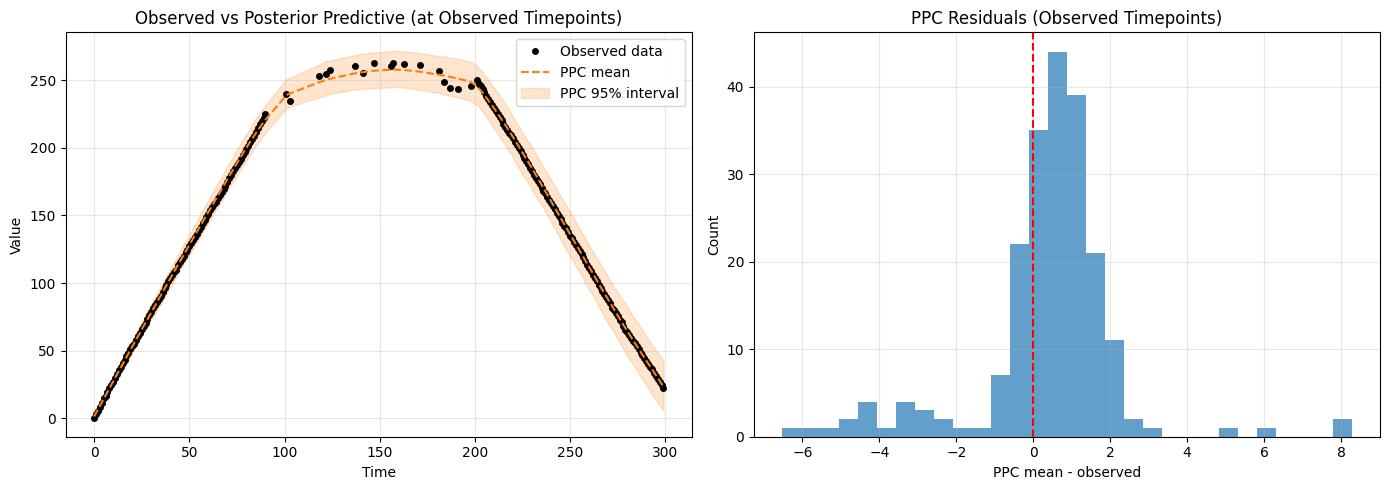

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(observed_idx, observed_vals, 'ko', markersize=4, label='Observed data')
ax.plot(observed_idx, ppc_mean, color='tab:orange', linestyle='--', label='PPC mean')
ppc_lower = np.percentile(ppc_samples, 2.5, axis=0)
ppc_upper = np.percentile(ppc_samples, 97.5, axis=0)
ax.fill_between(observed_idx, ppc_lower, ppc_upper, color='tab:orange', alpha=0.2, label='PPC 95% interval')
ax.set_title('Observed vs Posterior Predictive (at Observed Timepoints)')
ax.set_xlabel('Time')
ax.set_ylabel('Value')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
resid = ppc_mean - observed_vals
ax.hist(resid, bins=30, color='tab:blue', alpha=0.7)
ax.axvline(x=0, color='red', linestyle='--')
ax.set_title('PPC Residuals (Observed Timepoints)')
ax.set_xlabel('PPC mean - observed')
ax.set_ylabel('Count')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Model Diagnostics

In [9]:
print("=== MODEL DIAGNOSTICS ===")
print(f"\nData shape: {test_data.shape}")
print(f"Fraction missing: {np.isnan(test_data).mean():.2f}")
print(f"Number of states: {n_states}")
print(f"ADVI iterations: {n_fit}")
print(f"Final ELBO: {approx.hist[-1]:.2f}")

print(f"\n=== PARAMETER ESTIMATES ===")
print("Innovation Means (mu):")
for i in range(n_states):
    est_mean = mu_mean[i]
    est_std = mu_samples[..., i].std()
    print(f"  State {i + 1}: {est_mean:.3f} +/- {est_std:.3f} (true: {state_means[i]:.3f})")

print("\nParticipation Probability:")
for i in range(n_states):
    est_p = participation_mean[i]
    est_p_std = participation_samples[..., i].std()
    print(f"  State {i + 1}: {est_p:.3f} +/- {est_p_std:.3f}")

print("\nChangepoints (tau):")
for i in range(len(transition_points)):
    est_cp = tau_mean[i]
    est_std = tau_samples[..., i].std()
    print(f"  CP {i + 1}: {est_cp:.1f} +/- {est_std:.1f} (true: {transition_points[i]})")

elbo_diff = np.diff(approx.hist[-100:])
print(f"\n=== CONVERGENCE ===")
print(f"Mean ELBO change (last 100 iter): {elbo_diff.mean():.4f}")
print(f"Std ELBO change (last 100 iter): {elbo_diff.std():.4f}")

=== MODEL DIAGNOSTICS ===

Data shape: (300,)
Fraction missing: 0.31
Number of states: 3
ADVI iterations: 15000
Final ELBO: 56778.46

=== PARAMETER ESTIMATES ===
Innovation Means (mu):
  State 1: 2.396 +/- 0.091 (true: 2.500)
  State 2: 0.170 +/- 0.174 (true: 0.000)
  State 3: -2.293 +/- 0.101 (true: -2.300)

Participation Probability:
  State 1: 0.951 +/- 0.023
  State 2: 0.484 +/- 0.173
  State 3: 0.946 +/- 0.023

Changepoints (tau):
  CP 1: 99.3 +/- 3.8 (true: 90)
  CP 2: 198.4 +/- 3.8 (true: 200)

=== CONVERGENCE ===
Mean ELBO change (last 100 iter): -8415.0875
Std ELBO change (last 100 iter): 434829.2482


## Model Selection: Using ELBO to Identify the Number of States

`find_best_states` fits the model across a range of candidate state counts and picks the one with the lowest final ELBO. It does not directly use `participation_prob` (only `tau`/`mu`/`sigma`), but still provides a useful cross-check on the number of underlying states. As with the sibling `RandomWalkChangepointMeanVar1D` model, ADVI/ELBO comparisons are inherently noisy, so this is typically accurate to within +/-1 state rather than exact on every run.

Fitting model with 2 states
Fitting: ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 Average Loss = 5.2116e+05
Fitting model with 3 states
Fitting: ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 Average Loss = 1.5497e+06
Fitting model with 4 states
Fitting: ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 Average Loss = 6.1706e+05
Fitting model with 5 states
Fitting: ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 Average Loss = 9.1657e+05
ELBO by state count: {2: 479613.1, 3: 993363.52, 4: 410827.07, 5: 486896.72}
Selected number of states (lowest ELBO): 4 (true: 3)


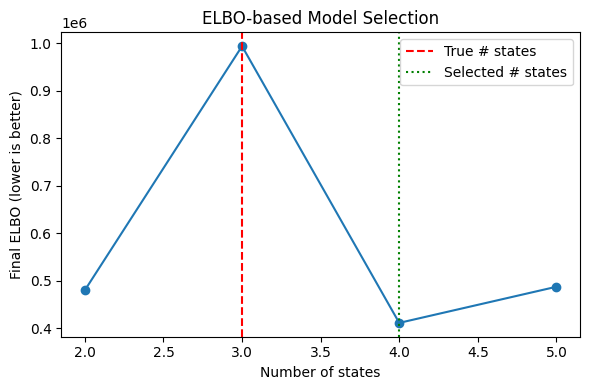

In [10]:
min_states, max_states = 2, 5
best_model, model_list, elbo_values = find_best_states(
    test_data[~np.isnan(test_data)],  # find_best_states does not handle NaNs
    random_walk_changepoint_participation_1d,
    n_fit=6000,
    n_samples=200,
    min_states=min_states,
    max_states=max_states,
)

state_range = np.arange(min_states, max_states + 1)
best_n_states = state_range[np.argmin(elbo_values)]

print(f"ELBO by state count: {dict(zip(state_range, np.round(elbo_values, 2)))}")
print(f"Selected number of states (lowest ELBO): {best_n_states} (true: {n_states})")

plt.figure(figsize=(6, 4))
plt.plot(state_range, elbo_values, 'o-')
plt.axvline(x=n_states, color='red', linestyle='--', label='True # states')
plt.axvline(x=best_n_states, color='green', linestyle=':', label='Selected # states')
plt.xlabel('Number of states')
plt.ylabel('Final ELBO (lower is better)')
plt.title('ELBO-based Model Selection')
plt.legend()
plt.tight_layout()
plt.show()

**Note:** for this cross-check, `find_best_states` is run on the observed (non-missing) subset of the data with the NaN gap effectively removed, since `find_best_states`/`advi_fit` do not thread through the `NaN`-tolerant handling that `RandomWalkChangepointParticipation1D` itself implements internally. This is only used here as an approximate sanity check on the number of states, not as the recommended fitting path -- fit the model directly on the full array with gaps, as done above, for real analyses.

## Summary

This notebook demonstrated:
1. **Data Generation**: Creating a synthetic 1D random walk with a disengaged/non-participating state whose innovations are zero-mean, high-variance, and mostly missing (`NaN`) in the observed data.
2. **Model Initialization**: Setting up `RandomWalkChangepointParticipation1D`, which extends the random walk changepoint model with a per-state, changepoint-blended participation probability and a `NaN`-tolerant latent-path/partial-observation likelihood split.
3. **Model Fitting**: Using ADVI (with a fixed random seed) to fit the model to data containing missing observations.
4. **Parameter Extraction**: Extracting and comparing fitted innovation means/stds, participation probabilities, and changepoint locations against the true generating parameters -- correctly identifying the disengaged state as having the lowest participation probability.
5. **Posterior Predictive Checks**: Comparing posterior predictive draws of the observation likelihood against the data at observed timepoints.
6. **Model Selection**: Using ELBO comparisons (`find_best_states`) as an approximate cross-check on the number of states.